# <center>Medical Imaging</center><br><center>Practical session 1: Image formation and reconstruction  (03/10/23)</center>
***
*Jens Maebe, Maya Abi Akl, Boris Vervenne, Meysam Dadgar* <br>
*MEDISIP, Ghent University* <br>

Name : Mehran Khodadadzadeh 0595580


# General
In total, there will be 4 practical sessions. For every session you should hand in a report **in groups of 2**. These reports will count for 5 out of 20 points for the exam. The topics of the sessions:

1. Image reconstruction in tomography, CT (25%)

2. Monte Carlo simulations, PET (25%)

3. Image processing part I (25%)

4. Image processing part II (25%)

***
Report (this notebook) due **2 weeks** after the session, the day before the next practical

- Concise and to the point answers to the questions

- Show that you understood what was going on and what the purpose of the exercise was

- Illustrate with figures (do not forget labels, legend, colorbar etc.)

- Hand in your **notebook** in **.ipynb** and **.html** format (File -> Download as -> HTML) via UFORA

- It is normal that some pictures in the text are missing in the .html file, as long as your own plots show up correctly.

***
We are here to help you: ask questions!
- During the sessions
- Via mail:
    - Maya.AbiAkl@UGent.be
    - Boris.Vervenne@UGent.be
    - Meysam.Dadgar@UGent.be
    - Jens.Maebe@UGent.be
***
**In order to avoid problems with conflicting packages, we recommend creating a new virtual environment specifically for this course:**

- if using `conda`: https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html
- if using `pip`: https://docs.python.org/3/library/venv.html

If you do, make sure you install and launch jupyter in this new environment.
***
**Deadline for this session: Monday 16 October 2023 at 23:59**.

# 1. Image formation
## 1.1 Fanbeam transform
In a CT scanner, the photon source is an X-ray tube. To make things easier, we approximate it as an infinitesimally small point source (figure 1).

<table>
    <tr>
        <td><img src="images/CT_schematic.jpg" width="300"/><figcaption><center>(a)</center></figcaption></td>
        <td><img src="images/CT_open.jpg" width="300"/><figcaption><center>(b)</center></figcaption></td>
    </tr>
</table>

<center><i>Figure 1: (a) The different parts of a CT-scanner. (b) The inside of a CT scanner with the different parts and coordinates indicated.</i></center>

From this point source, photons are fired through the patient's body. The curved detector on the other side of the patient will detect the photons which have not been attenuated along their path through the body. Because we knew the number of fired photons ($I_0$), we can calculate the attenuation from the Beer-Lambert law:
\begin{equation}
	I=\int I_0\left(E\right) e^{-\int_0^L\mu(\vec{x},E) d\vec{x}} dE,
\end{equation}

with $I$ the number of detected photons (quanta) in a detector pixel, $E$ the photon energy (remember, X-rays generated by an X-ray tube are always polyenergetic!), $\mu$ the attenuation coefficient and $\vec{x}$ a vector representing the spatial coordinate along the line, from $0$ to $L$. If we ignore the energy spectrum for now and try to determine $\int \mu(\vec{x}) d\vec{x}$, we first have to calculate the log-attenuated values:

\begin{equation}
\int_0^L \mu(\vec{x}) d\vec{x} = \log\left(I_0\right) - \log\left( I \right).
\end{equation}

<table>
    <tr>
        <td><img src="images/fanbeam.jpg" width="300"/><figcaption><center>(a)</center></figcaption></td>
        <td><img src="images/parbeam.jpg" width="300"/><figcaption><center>(b)</center></figcaption></td>
    </tr>
        <td><img src="images/fansino.jpg" width="300"/><figcaption><center>(c)</center></figcaption></td>
        <td><img src="images/parsino.jpg" width="300"/><figcaption><center>(d)</center></figcaption></td>
    <tr>
</table>
<center><i>Figure 2: (a) The geometry of a fanbeam projection, (b) parallel beam projection, (c) a sinogram obtained from a fanbeam, (d) and parallel beam projection.
</i></center>

These so-called path lengths are what will be used for the rest of the practicum session.

The ideal path followed by each photon can be represented by a line connecting the X-ray source with the place of detection. All lines (for all detector pixels) for one rotation angle together form one fan beam projection (figure 2(a)). This represents one line in the sinogram. If we now rotate the source-detector pair around the patient and sample on different angles, a complete sinogram is obtained.

This measured sinogram, containing data acquired from different angles, is the only data received from a CT scanner. This data can be used to directly reconstruct the original object in 3D. However, in this exercise lesson, we will reconstruct only from parallel projections and not from fan beam projections. Therefore, the fan beam projections have to be converted (a.k.a. rebinned) to parallel projection data.

## 1.2 The radon transform
Figure 2(c) and 2(d) respectively show sinograms obtained in fanbeam geometry and a parallel beam geometry. Forward projecting in a parallel beam geometry can be described mathematically by the Radon transform $R(\theta,x^\prime)$:
\begin{equation}
	R(\theta,x^\prime)= \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x,y)\delta(x^\prime - (x\cos\theta+y\sin\theta)) dx dy.
\end{equation}
Here, $f(x,y)$ represents the distribution of the attenuation coefficients in the body.
The Radon transform $R(\theta=\Theta,x\prime=X^\prime)$ can be interpreted as the sum (if we discretize $f(x,y)$ in pixels) of the attenuation coefficients at rotation angle $\Theta$ along a line perpendicular to the $x^\prime$-axis, crossing this axis at $X^\prime$. $x^\prime$ can be calculated from $\theta$, $x$ and $y$ as:
\begin{equation}
x^\prime= x \cos\theta +y \sin\theta,
\end{equation}
which is just a rotated $x$. These data can then be reconstructed by using the inverse of the Radon transform.

## <font color='blue'>Exercise 1: Parallel beam projection</font>
In this exercise you will create a virtual CT scanner data. However, unlike in reality, we will assume a perfect parallel beam which allows us to use the Radon transform for this projection. For this exercise and the following, we will use the scikit-image (`skimage`) package of python (https://scikit-image.org/).   

Start by creating an empty 64x64 image (2D matrix) where you add a point (cluster of 2x2 pixels with value 1) somewhere off-center. Project this data over a 360° angular range using 360 projection angles by making use of the `radon` function from scikit-image (`skimage.transform.radon`).

Repeat this with an 8 pixel long off-center 'line' instead of a point.

### <font color='blue'> Report</font>
<font color='blue'>In your report, we expect to see the two images you used with their sinograms. Explain the differences you see between both sinograms and reinforce your answer by making use of overlapping profiles (line plots) of the sinograms at certain angles. </font>

<font color='red'> SOLUTION: </font>

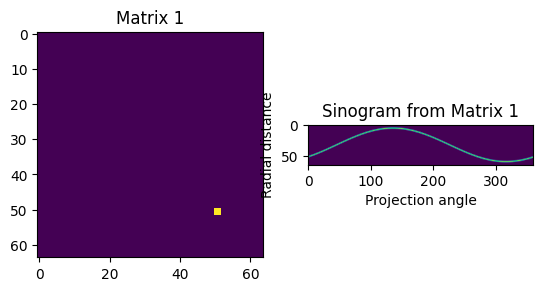

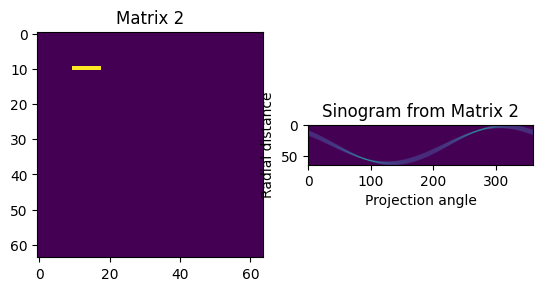

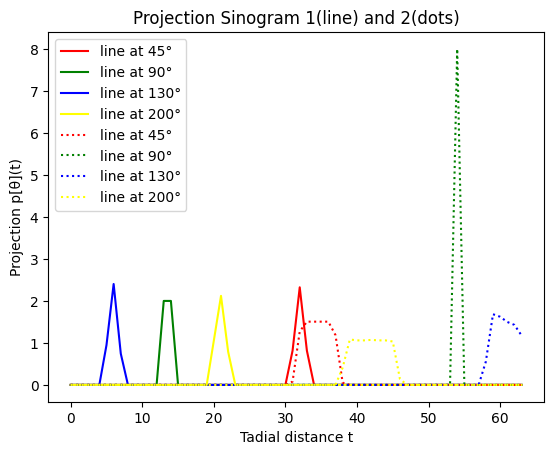

In [ ]:
# Import numpy, matplotlib.pyplot and from skimage.transform import radon
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon

# Create two 64x64 matrices filled with zeros
matrix_1_ex1 = np.zeros((64, 64))
matrix_2_ex1 = np.zeros((64, 64))

# Matrix 1 with a 2x2 cluster of 1s(placed at coordinates (50,50) to (51,51))
matrix_1_ex1[50:52, 50:52] = 1

# Matrix 2 with a 1x8 row of 1s(spanning columns 10 to 17)
matrix_2_ex1[10, 10:18] = 1

# Radon transformation on both matrices (360 degrees covering a full circle)
sinogram_1_ex1 = radon(matrix_1_ex1, np.arange(360))
sinogram_2_ex1 = radon(matrix_2_ex1, np.arange(360))

# Plot Matrix 1 and its Sinogram 1(A sinogram represents how much of an X-ray beam is absorbed at different angles and distances as it passes through the object)
plt.figure(1)

plt.subplot(1, 2, 1)
plt.imshow(matrix_1_ex1)
plt.title('Matrix 1')

plt.subplot(1, 2, 2)
plt.imshow(sinogram_1_ex1)
plt.title('Sinogram from Matrix 1')
plt.xlabel('Projection angle')
plt.ylabel('Radial distance')

# Plot Matrix 2 and its Sinogram 2
plt.figure(2)

plt.subplot(1, 2, 1)
plt.imshow(matrix_2_ex1)
plt.title('Matrix 2')

plt.subplot(1, 2, 2)
plt.imshow(sinogram_2_ex1)
plt.title('Sinogram from Matrix 2')
plt.xlabel('Projection angle')
plt.ylabel('Radial distance')

plt.show()

# Line plots
plt.figure(3)

# Line
plt.plot(sinogram_1_ex1[:,45], color='red', label='line at 45°') # 45º
plt.plot(sinogram_1_ex1[:,90], color='green', label='line at 90°') # 90º
plt.plot(sinogram_1_ex1[:,130], color='blue', label='line at 130°')# 130º
plt.plot(sinogram_1_ex1[:,200], color='yellow', label='line at 200°') # 200º
plt.title('Projection Sinogram 1')

# Dots
plt.plot(sinogram_2_ex1[:,45], color='red', linestyle='dotted', label='line at 45°') # 45º
plt.plot(sinogram_2_ex1[:,90], color='green', linestyle='dotted', label='line at 90°') # 90º
plt.plot(sinogram_2_ex1[:,130], color='blue', linestyle='dotted', label='line at 130°')# 130º
plt.plot(sinogram_2_ex1[:,200], color='yellow', linestyle='dotted', label='line at 200°') # 200º
plt.title('Projection Sinogram 1(line) and 2(dots)')

plt.xlabel('Tadial distance t')
plt.ylabel('Projection p[\u03B8](t)')
plt.legend()
plt.show()




<font size="3">In the code, the variable matrix_1 represents a 2x2 cluster of pixels in a 64x64 matrix. the The result after applying the Radon transformation is a sinogram with a single prominent line. This is because the 2x2 pixel cluster represents a simple geometric shape that, when projected from different angles, creates a single line in the sinogram.

<font size="3">The variable matrix_2 represents a 1x8 row of pixels in a 64x64 matrix. When this matrix is transformed into sinogram_2, the sinogram contains multiple similar lines grouped together. This happens because the 1x8 row, when projected from various angles, generates multiple lines in the sinogram.

<font size="3">This part of the explanation emphasizes that the code not only creates sinograms for the two different matrix shapes but also displays how these sinograms vary when projected over different angles (from 0 to 359 degrees).


## <font color='blue'>Exercise 2: the sinogram</font>
To understand the content of a sinogram, we will take a closer look at the relation between an image and its sinogram. Therefore, start by making an image containing four points (each a cluster of 2x2 pixels). The first point should be in the center, the three other points should be located off-center, at different distances from the center. Make use of the `radon` function in scikit-image to project the image to sinogram space.

### <font color='blue'> Report</font>
<font color='blue'>Plot the original image and show it together with its sinogram obtained from a 360° and a 180° angular range. Use 90 projection angles in both cases.

<font color='red'> SOLUTION: </font>

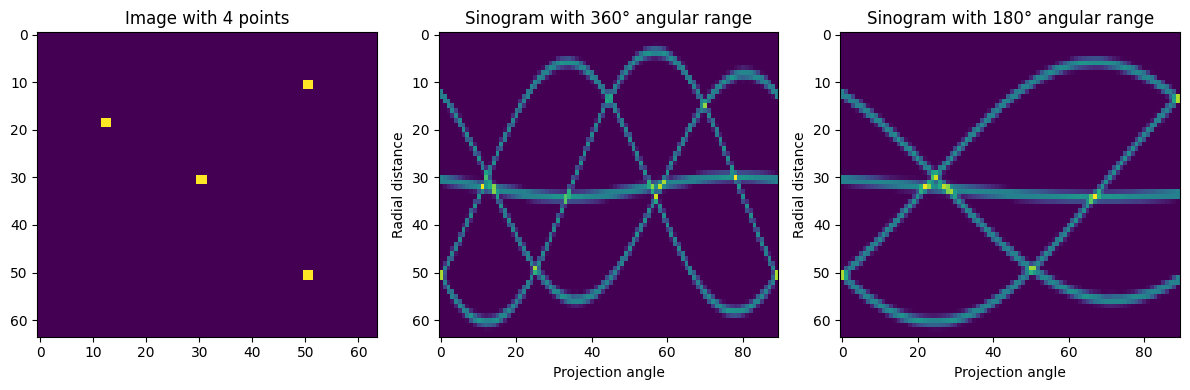

In [ ]:
# Import numpy, matplotlib.pyplot and from skimage.transform import radon
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon

# Create a 64x64 matrix with four points
matrix_1_ex2 = np.zeros((64, 64))
matrix_1_ex2[30:32, 30:32] = 1
matrix_1_ex2[50:52, 50:52] = 1
matrix_1_ex2[18:20, 12:14] = 1
matrix_1_ex2[10:12, 50:52] = 1

# Perform Radon transforms with 360 and 180 angular ranges
sinogram_1_ex2 = radon(matrix_1_ex2, np.linspace(0, 360, 90))  # 360º
sinogram_2_ex2 = radon(matrix_1_ex2, np.linspace(0, 180, 90))  # 180º

# Plot image and sinogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(matrix_1_ex2, aspect='auto')
plt.title('Image with 4 points')

plt.subplot(1, 3, 2)
plt.imshow(sinogram_1_ex2, aspect='auto')
plt.title('Sinogram with 360° angular range')
plt.xlabel('Projection angle')
plt.ylabel('Radial distance')

plt.subplot(1, 3, 3)
plt.imshow(sinogram_2_ex2, aspect='auto')
plt.title('Sinogram with 180° angular range')
plt.xlabel('Projection angle')
plt.ylabel('Radial distance')

plt.tight_layout()
plt.show()


# REVIEWWW

<font color='blue'>Why do we call this a sinogram?

<font size="3"> Because it depicts the data obtained during a CT (Computed Tomography) scan in a sinusoidal manner, a sinogram receives its name. Each projection is represented as a sinusoidal curve in the sinogram, and the projections were obtained from various angles all around the patient.

<font color='blue'>What is the relation between the sinogram and the position in the original image?

<font size="3"> Each point in the original image corresponds to a sinusoidal projection in the sinogram, and the phase of the sinusoid changes depending on the position of the point in the image.

<font color='blue'>Would you use the 360° or the 180° angular range when the number of projection angles is fixed? Why?

<font size="3"> Choosing the angular range: A 180° angular range is frequently used when the number of projection angles is fixed. This is due to the fact that a parallel beam projector used for CT imaging typically has a 180-degree field of view. A 360° angle range would provide redundant data and lengthier scan times without noticeably improving image quality.


## <font color='blue'>Exercise 3: the sinogram (continued)</font>
To get an even better feel of what kind of data is included in a sinogram, download the file **Abdomen.bin** from Ufora and open it. This data is a slice of an in-vivo abdominal scan of a mouse, measured with a cone-beam micro-CT system in the Infinity lab. We already rebinned the cone-beam sinogram to parallel beam geometry for you and below you can find the code to import the sinogram data. Make use of the `iradon` function from scikit.image (`skimage.transform.iradon`) to reconstruct the sinogram into an image.

### <font color='blue'> Report</font>
<font color='blue'>Answer these questions:

<font color='blue'>- What is wrong with this image?

The image obtained from the CT scan exhibits a ring artifact. A ring artifact is characterized by concentric circular or ring-shaped patterns that are not part of the actual scanned object. These artifacts degrade the quality of the image and can obscure important details. In this specific image, the ring artifact is visible as circular patterns that distort the representation of the mouse's abdominal structure.

<font color='blue'>- What could be the physical cause (a scanner problem) of this? (Think about all elements contained in a CT system!)

Detector Issues: Uneven detector sensitivity creates uneven signals, making ring-shaped artifacts in both the sinogram and image.

 Data Gaps: Missing or noisy scan data causes rings in the final image due to incomplete information.

Geometry Mistakes: Errors in how the CT scanner's parts are set up, like the detectors and X-ray source, can create inaccuracies, leading to ring artifacts.

Beam Changes: When X-rays are absorbed differently by the object, it results in shading rings in the image, caused by something called beam hardening.

- Correct for this artefact on the sinogram; plot the improved image and explain what you did</font>

**For Correction of the Artifact in the Sinogram,we did some steps** :

1-Identifying the Artifact: You initially detected the presence of a ring artifact in the middle of the sinogram by plotting specific rows of the sinogram data. This allowed you to pinpoint the problem.

2-Artifact Location: The artifact was primarily centered around detector 305 in the sinogram.

3-Replacing Detector 305 Value: To correct the artifact, you decided to replace the value in detector 305 (sinogram[305]) with a more accurate representation.

4-Average Calculation: You calculated the average value of signal strength from neighboring detectors, specifically detectors 301, 302, 303, 304, 306, and 307. This average value was computed to ensure a more consistent and reliable representation of the data.

5-Replacing the Value: The calculated average value was then assigned to detector 305, effectively replacing the problematic data with a more representative value.

**Plotting the Improved Image**:

1-Displaying Modified Sinogram: After correcting the sinogram by replacing the value in detector 305, you plotted the modified sinogram (sinogram1). This image no longer contained the ring artifact.

2-Improved Visualization: The improved sinogram allowed for a more accurate and artifact-free representation of the scan data.

3-Reconstruction of the Image: Using the iradon function, you reconstructed an image from the improved sinogram (sinogram1). This reconstructed image (image_2) now provided a clearer and more reliable visualization of the mouse's abdominal structure, free from the ring artifact that previously obscured the details.

In [ ]:
import numpy as np

with open("Abdomen.bin", 'rb') as f:
    data = np.fromfile(f, dtype=np.float64)
    sinogram = np.transpose(np.reshape(data, [360,729]))

<font color='red'> SOLUTION: </font>

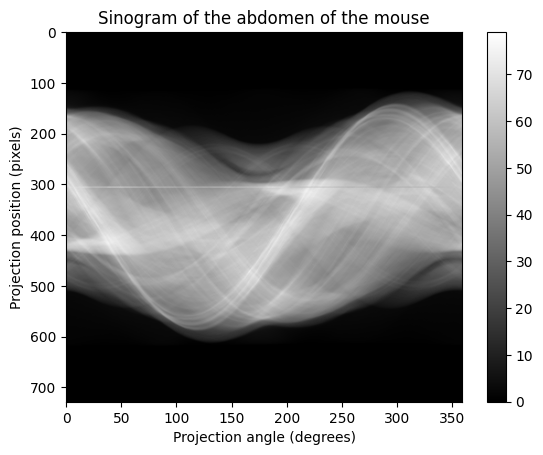

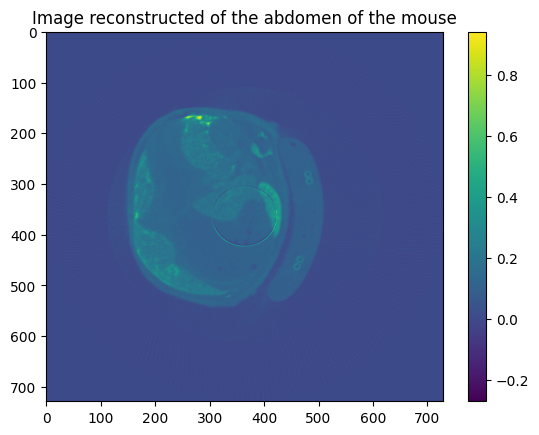

In [ ]:
# From skimage.transform import iradon
from skimage.transform import iradon

# Plot Sinogram of the abdomen of the mouse
plt.imshow(sinogram, cmap='grey',aspect='auto')
plt.title('Sinogram of the abdomen of the mouse')
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection position (pixels)')
plt.colorbar()
plt.show()

# We use iradon to recounstruct the image from the sinogram
image_ex3 = iradon(sinogram, np.arange(360))
plt.imshow(image_ex3, aspect='auto')
plt.title('Image reconstructed of the abdomen of the mouse')
plt.colorbar()
plt.show()



There is an ring artifact en the middle of the sinogram

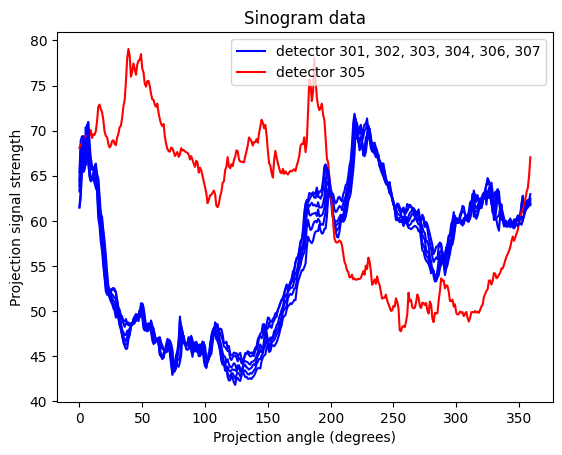

In [ ]:
# Finding the artifact
plt.plot(sinogram[301], color='blue')
plt.plot(sinogram[302], color='blue')
plt.plot(sinogram[303], color= 'blue', label = 'detector 301, 302, 303, 304, 306, 307')
plt.plot(sinogram[304], color= 'blue')
plt.plot(sinogram[305], color='red', label = 'detector 305')
plt.plot(sinogram[306], color= 'blue')
plt.plot(sinogram[307], color= 'blue')
plt.title('Sinogram data')
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection signal strength')
plt.legend()
plt.show()

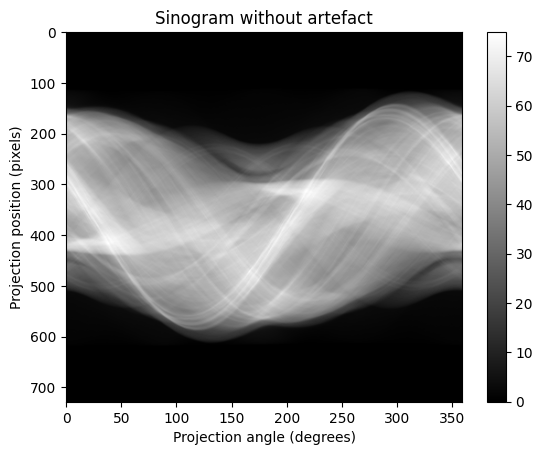

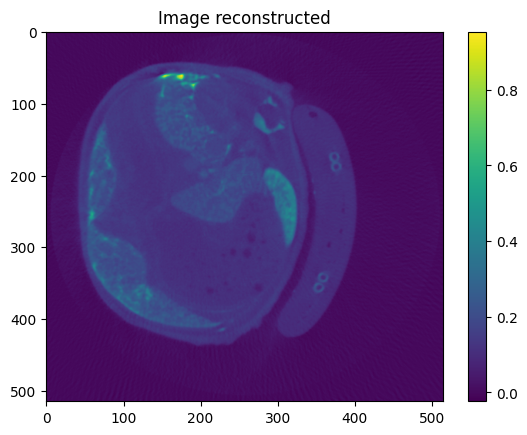

In [ ]:
# Delete artifact changing the value of 305 for an a average
value301 = sinogram[301]
value302 = sinogram[302]
value303 = sinogram[303]
value304 = sinogram[304]
value306 = sinogram[306]
value307 = sinogram[307]
num = [value301, value302, value303, value304, value306, value307]
average = sum(num)/len(num)
sinogram[305]=average
sinogram1=sinogram

# Plot image without artifact
plt.imshow(sinogram1, cmap='gray', aspect='auto')
plt.colorbar()
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection position (pixels)')
plt.title('Sinogram without artefact')
plt.show()

image_2 = iradon(sinogram1, np.arange(360), circle=False)
plt.imshow(image_2, aspect='auto')
plt.title('Image reconstructed')
plt.colorbar()
plt.show()

## <font color='blue'>Exercise 4: Build your own forward projector</font>
In medical image reconstruction, the name ‘projector’ or ‘forward projector’ is given to an operation
which transforms data from image space to projection space (the sinogram). In this exercise, we want
you to implement your own projector in Python, as an alternative to the `radon` function. Implement this projector by combining image rotation followed by summation along one axis. You should keep x' and sum along y'.

Start with a 256×256 image that you generate with the `shepp_logan_phantom()` function from `skimage.data`. Now use the functions `skimage.transform.rotate` and `np.sum` to perform projections and to build a sinogram. Use 360 projection angles over an angular range of 360 . Also use `radon` to forward project the original image, so we can compare your implementation to the one you try to mimic.


### <font color='blue'> Report</font>
<font color='blue'>Show the sinogram obtained with your own projector and compare to the sinogram obtained with the radon function. </font>

In [ ]:
from skimage.data import shepp_logan_phantom
from skimage.transform import rescale

image = shepp_logan_phantom()
image = rescale(image, scale=256/400) # rescale from 400x400 to 256x256

<font color='red'> SOLUTION: </font>

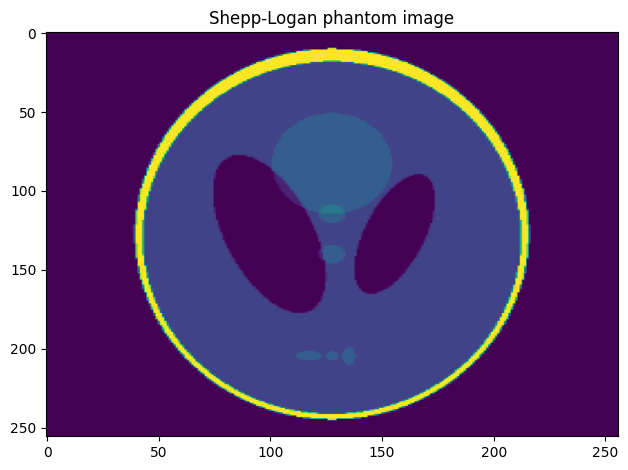

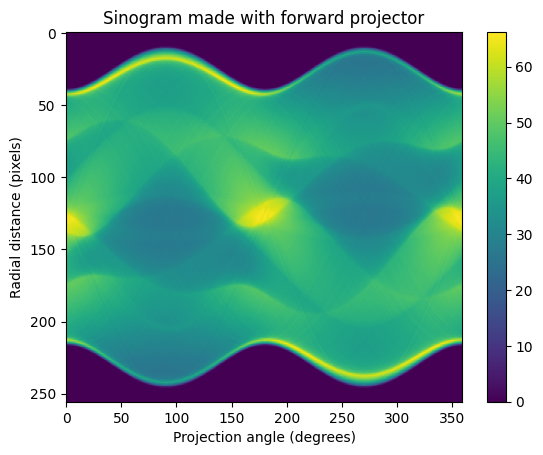

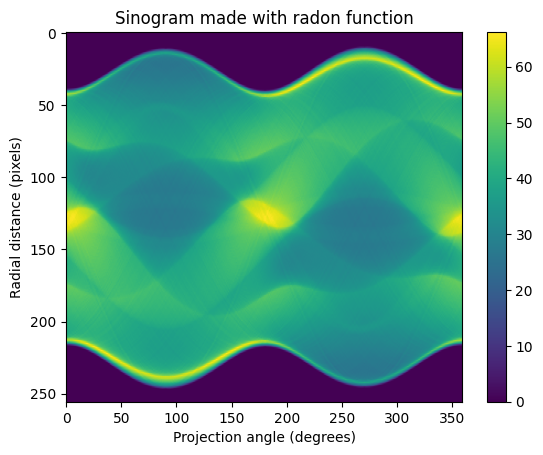

In [ ]:
# Import numpy and from skimage.transform import rotate
import numpy as np
from skimage.transform import rotate

# Plot imagen of Shepp-Logan phantom
plt.imshow(image, aspect='auto')
plt.title('Shepp-Logan phantom image')
plt.tight_layout()
plt.show()

# Contruction of forward proyector
# Initialize array for teh storage of the proyection data, after in the loop, it iterate 360 times
# Inside the loop the image is rotated and it's collected in an array of sum
sinogram_fp = np.zeros((256,360))
for i in range(360):
    rot1 = rotate(image,i)
    sinogram_fp[:,i] = np.sum(rot1, axis=0)

# Contruction of the sinogram from radon function
sinogram_radon = radon(image, np.arange(360), circle=True) # 360 degrees

# Plot Sinogram made from our own fp and from radon function
plt.figure(1)
plt.imshow(sinogram_fp, aspect='auto')
plt.title('Sinogram made with forward projector')
plt.ylabel('Radial distance (pixels)')
plt.xlabel('Projection angle (degrees)')
plt.colorbar()
plt.show()

plt.figure(2)
plt.imshow(sinogram_radon, aspect='auto')
plt.title('Sinogram made with radon function')
plt.ylabel('Radial distance (pixels)')
plt.xlabel('Projection angle (degrees)')
plt.colorbar()
plt.show()

They are nearly identical, but with a mirrored effect

## 2. Image reconstruction
### 2.1 Backprojection
The backprojection operation describes the transformation back from projection space to image space and it is the mathematical adjoint of the Radon transform:

\begin{equation}
B(x,y) =
\int_0^\pi R(\theta,x')d\theta
\end{equation}

Here, $B(x, y)$ represents the backprojected image, and $R(\theta, x′)$ is the sinogram. For one fixed angle $\Theta$, the backprojection $B(x, y; \theta = \Theta)$ is performed by smearing the values of $R(\theta = \Theta, x′)$ along perpendicular lines (Figure 4). If we repeat this operation for all angles $\theta$, the sum of all $B(x,y;\theta = \Theta)$ will form $B(x, y)$.

<table>
    <tr>
        <td><img src="images/backproj.jpg" width="300"/><figcaption><center>(a)</center></figcaption></td>
    </tr>
</table>
<center><i>Figure 4: Backprojection of all values of R(θ,x′) to a rotated image for a fixed angle Θ.
</i></center>


## <font color='blue'>Exercise 5: Build you own backprojector</font>
We can backproject the sinogram obtained in the previous exercise by first smearing $R(\theta = \theta,x′)$ into a rotated image. When we rotate this image back to the original position and sum over all angles, we obtain a backprojection of the sinogram. Again, use the functions `skimage.transform.rotate` and `np.sum` to implement a backprojector. Work on the sinogram you created in exercise 2.

### <font color='blue'> Report</font>
<font color='blue'> In your report:
- show your backprojection for 10 angles over a range of 0-360
- show your backprojection for 90 angles over a range of 0-360

Answer these questions:

<font color='blue'>What is the difference between the original image and your backprojection image?

<font size="3"> The backprojection images are noticeably blurrier than the original image due to limited projection angles, which introduce artifacts and blurring. Fine details are often lost in the backprojection process, particularly in complex areas, and noise can be more pronounced, impacting image fidelity.

<font color='blue'>How can the backprojection be improved?


1. **More Angles, Better Quality**: Having more projection angles is vital. It makes the images clearer by reducing unwanted patterns and keeping fine details intact.

2. **Smart Reconstruction Methods**: Using advanced reconstruction techniques matters a lot. Methods like Filtered Back Projection (FBP) are like smart puzzles solvers. They deal with noise, missing bits, and other tricky parts to create top-notch images.

3. **Silencing the Noise**: Noise reduction is a must. It's like removing static from a phone call. By reducing noise in the sinogram data, we get images that are cleaner, crisper, and more accurate.


<font color='red'> SOLUTION: </font>


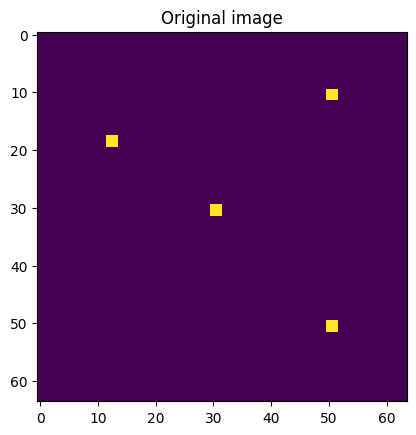

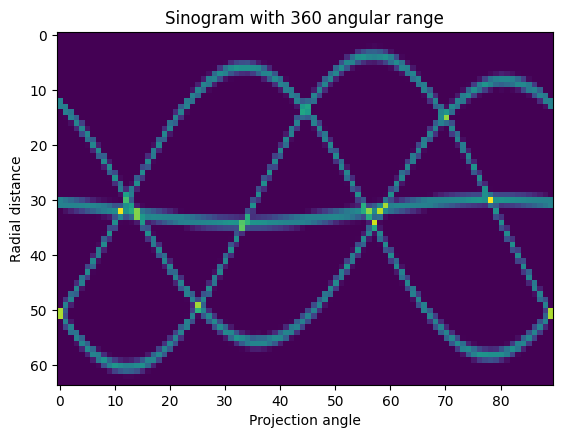

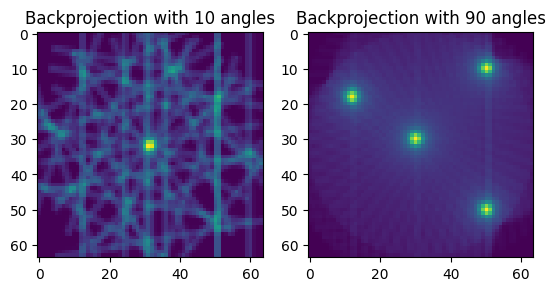

In [ ]:

# Import numpy, rotate from skimage.transfrom and repmat from numpy.matlib
import numpy
from skimage.transform import rotate
from numpy.matlib import repmat

# Plot original image
plt.imshow(matrix_1_ex2)
plt.title('Original image')
plt.show()

# Plot Sinogram from Ex2
plt.imshow(sinogram_1_ex2)
plt.title('Sinogram with 360 angular range')
plt.xlabel('Projection angle')
plt.ylabel('Radial distance')
plt.show()

# Backprojection for 10 angles
backproj_10 = np.zeros((64, 64))# Matrix  backprojection same dimensions as the original image
theta = np.linspace(0, 360, num=10) # Range of angles from 0 to 360 degrees divided into 90 spaced values
for i in range(len(theta)): # Iterate through each angle
    repl2 = repmat(sinogram_1_ex2[:, i], 64, 1) # Replicate the sinogram column to match the size of the original image
    rot2 = rotate(repl2, theta[i]) # Rotate the replicated sinogram column by the angle theta
    backproj_10 = backproj_10 + rot2

# Backprojection for 90 angles
backproj_90 = np.zeros((64, 64))# Matrix  backprojection same dimensions as the original image
alpha = np.linspace(0, 360, num=90) # Range of angles from 0 to 360 degrees divided into 90 spaced values
for i in range(len(alpha)): # Iterate through each angle
    repl3 = repmat(sinogram_1_ex2[:, i], 64, 1) # Replicate the sinogram column to match the size of the original image
    rot3 = rotate(repl3, alpha[i]) # Rotate the replicated sinogram column by the angle alpha
    backproj_90 = backproj_90 + rot3

# Plot backprojection with 10 and 90 angles
plt.figure(1)

plt.subplot(1, 2, 1)
plt.imshow(backproj_10)
plt.title('Backprojection with 10 angles')

plt.subplot(1, 2, 2)
plt.imshow(backproj_90)
plt.title('Backprojection with 90 angles')
plt.show()

## 2.3 Filtered backprojection
To understand the origin of the blur in the reconstructed image, take a look at the sampling in the Fourier domain.
Take the backprojection from a single angle:

\begin{equation}
B(x,y;\theta=\Theta) = R(\theta = \Theta,x')
\end{equation}

$$\begin{aligned}
\mathcal{B}(\nu_x,\nu_y;\theta=\Theta) &=& \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} B(x,y;\theta=\Theta) e^{-2\pi i(x\nu_x+y\nu_y)}dx dy \\
&=&  \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} R(\theta=\Theta,x^\prime) e^{-2\pi i(x\nu_x+y\nu_y)}dx^\prime dy^\prime \\
&=& \mathcal{R}(\theta=\Theta,\nu_{x^\prime}) \delta(\nu_{y^\prime}) \\
\end{aligned}$$

From the central slice theorem (course notes) we know that $\mathcal{R}(\theta=\Theta,\nu_{x^\prime})=\mathcal{F}(\nu_x,\nu_y)\mid_{\nu_{y^\prime}=0}$. Thus, **every backprojection along 1 angle is actually equal to one line of the Fourier transform of the original image!** Superimposing all lines and then taking the inverse Fourier transform would result in our blurry backprojection image. In other words, the blur in the reconstructed image arises from the fact that the center of the Fourier space will be oversampled due to the radial sampling. You get an overestimation of the low frequency components and an underestimation of the high frequency components. This is illustrated in figure 5.

<table>
    <tr>
        <td><img src="images/sampling_fourier.jpg" width="300"/><figcaption><center>(a)</center></figcaption></td>
        <td><img src="images/grid.jpg" width="300"/><figcaption><center>(b)</center></figcaption></td>
        <td><img src="images/ramp.jpg" width="300"/><figcaption><center>(c)</center></figcaption></td>
</table>
<center><i>Figure 5: (a) Sampling of the Fourier space using 20 backprojections. (b) The radial grid on which the Fourier space is sampled. (c) The ramp filtered used to compensate for the oversampling.
</i></center>

To compensate for the oversampling at lower frequencies, you should use a filter which is proportional to the circumference of a circle defined with radius $\nu =\sqrt{\nu_x^2+\nu_u^2}$. Proportionality with the circumference is equal to proportionality with the radius. Thus our filter will be $\nu$, also called a ramp filter (Figure 5(c)). Thanks to the above, we can discriminate three ways to get to our filtered backprojection, of which the second is the simplest and will be used in the next exercise:

1. **Projections** $\rightarrow$ backprojection $\rightarrow$ 2D FT $\rightarrow$ filter with 2D ramp filter $\rightarrow$ 2D IFT $\rightarrow$ **Filtered reconstructed image**
2. **Projections** $\rightarrow$ 1D FT $\rightarrow$ filter with 1D ramp filter $\rightarrow$ 1D IFT $\rightarrow$ backprojection $\rightarrow$ **Filtered reconstructed image**
3. **Projections** $\rightarrow$ backprojection $\rightarrow$ superimposing all lines in correct angle $\rightarrow$ interpolation to get more uniform grid in 2D FT space $\rightarrow$ 2D IFT $\rightarrow$ **Filtered reconstructed image**


## <font color='blue'>Exercise 6: Filtered backprojection</font>
In this exercise, you will have to solve the problem of oversampling with the second method. Work with the sinogram obtained with radon in exercise 4 (Shepp-Logan phantom). Use all 90 angles. First you will have to transform the sinogram to Fourier space. Next, filter your projection data using a ramp filter. After returning to sinogram space with an inverse Fourier transform, backproject the filtered sinogram using your backprojector from the previous exercise. Compare your result to the result of applying `iradon(..., filter_name="ramp")` to your unfiltered sinogram data. Also compare with your own backprojector without filtering.

### Remark
Make use of the `np.fft.rfft` and `np.fft.irfft` functions to perform the Fourier and inverse Fourier transforms on a real-valued input. This only computes the positive frequencies, so our ramp filter should also only be defined for the positive frequencies (see code below).

### <font color='blue'> Report</font>
<font color='blue'>
Plot an image of both your own filtered and unfiltered reconstructions and the iradon-backprojection. Also show the original and filtered sinograms. Is the result better with filtering? Limit the number of angles to 20. What happens now?</font>


When we compared filtered and unfiltered reconstructions using just 20 angles from the Shepp-Logan sinogram, it became clear that filtering is key to getting better image quality. Filtered reconstruction visibly reduced image artifacts, making the image sharper and more accurate. Although the differences may not always be huge, filtering generally helps improve accuracy. Success here depends on various factors like the quality of the data, the choice of filter, the number of angles used, and the nature of the object being imaged. It highlights the importance of finding the right balance among these factors for top-notch medical imaging results.

In [ ]:
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import rescale

image = shepp_logan_phantom()
image = rescale(image, scale=256/400)
ramp = np.linspace(0, 1, num=256//2 + 1)

<font color='red'> SOLUTION: </font>

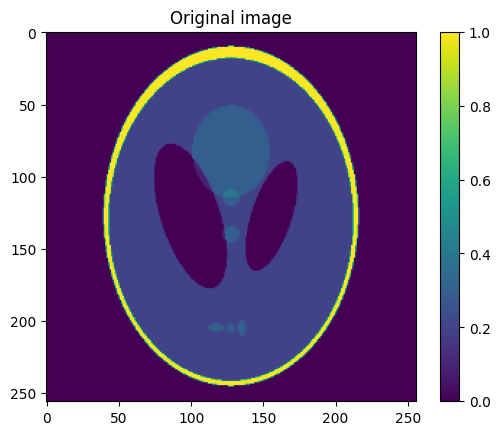

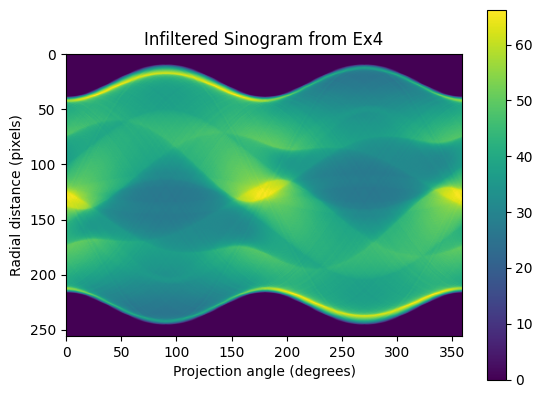

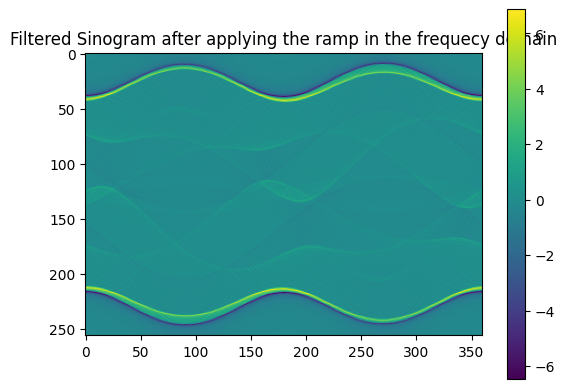

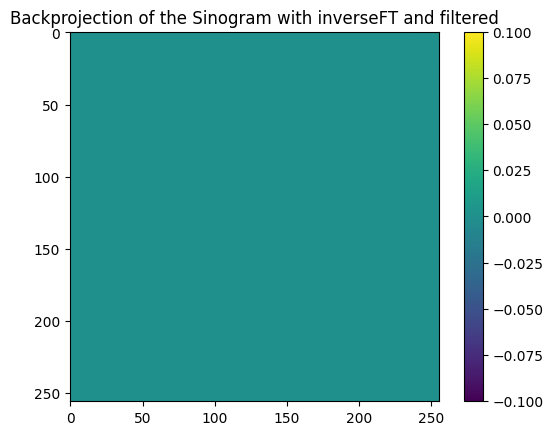

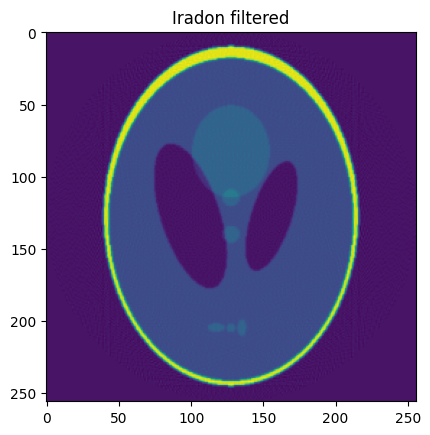

In [ ]:
# Backprojection for 90 angles
backproj_90 = np.zeros((256, 256))# Matrix  backprojection same dimensions as the original image
betha = np.linspace(0, 360, num=90) # Range of angles from 0 to 360 degrees divided into 90 spaced values
for i in range(len(betha)): # Iterate through each angle
    repl4 = repmat(sinogram_radon[:, i], 256, 1) # Replicate the sinogram column to match the size of the original image
    rot4 = rotate(repl4, betha[i]) # Rotate the replicated sinogram column by the angle alpha
    backproj_90 = backproj_90 + rot4

# Plot original image
plt.imshow(image)
plt.title('Original image')
plt.colorbar()
plt.show()

# Plot sinogram with frontproyection from Ex4 and a sinogram with backprojection (radon)
plt.imshow(sinogram_fp)
plt.colorbar()
plt.title('Infiltered Sinogram from Ex4')
plt.ylabel('Radial distance (pixels)')
plt.xlabel('Projection angle (degrees)')
plt.show()


# Filtered sinogram made by fp with the radon funcion
sinogram_FFT = np.fft.rfft(sinogram_radon, axis=0) # FTT
for i in range(360): # add ramp filter
    sinogram_FFT[:, i] = sinogram_FFT[:, i]*ramp
sinogram_iFFT = np.fft.irfft(sinogram_FFT, axis=0) # FTT^-1 to obtain filtered sinogram

# Plot filtered sinogram
plt.imshow(sinogram_iFFT)
plt.colorbar()
plt.title('Filtered Sinogram after applying the ramp in the frequecy domain')
plt.show()

# Filtered backprojection

# Backprojection of the sinogram
sinogram_bp_f = np.zeros((256, 256))
omega = np.linspace(0,360, num = 90)
for i in range(90):
    repl4 = repmat(sinogram_iFFT[:, i], 256, 1)
    rotation_ex6_2 = rotate(repl4, omega[i])
    rot4 = np.add(sinogram_bp_f, rot4)

plt.imshow(sinogram_bp_f)
plt.colorbar()
plt.title('Backprojection of the Sinogram with inverseFT and filtered')
plt.show()

# iradon-backprojection
iradon_f = iradon(sinogram_radon, np.arange(360), filter_name='ramp') # Ramp filter

# Plot iradon filtered

plt.imshow(iradon_f)
plt.title('Iradon filtered')
plt.show()
